# PCA From Scratch

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Data Analysis

In [2]:
df = pd.read_csv('./data/breast-cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
px.histogram(data_frame=df, x='diagnosis', color='diagnosis', color_discrete_sequence=['#05445e', '#75e6da'])

From the above histogram, it is very clear that categories are imbalanced in terms of count

In [4]:
px.histogram(data_frame=df,x='area_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [5]:
px.histogram(data_frame=df,x='radius_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [6]:
px.histogram(data_frame=df,x='perimeter_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [7]:
px.histogram(data_frame=df,x='smoothness_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [8]:
px.histogram(data_frame=df,x='texture_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [9]:
px.scatter(data_frame=df,x='symmetry_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [10]:
px.scatter(data_frame=df,x='concavity_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [11]:
px.scatter(data_frame=df,x='fractal_dimension_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

From the histograms and scatter plots we plot above, there are no particular features that indicate strong noncorrelation, we thus would need a more robust approach to reduce the number of features for future analysis. This is when PCA (principal component analysis comes into play).

### Data Processing

In [12]:
df.drop('id', axis= 1, inplace = True)

#### Encode the target

In [13]:
df['diagnosis'] = (df['diagnosis'] == 'M').astype(int) # encode the label into 1/0

#### Get highly correlated features

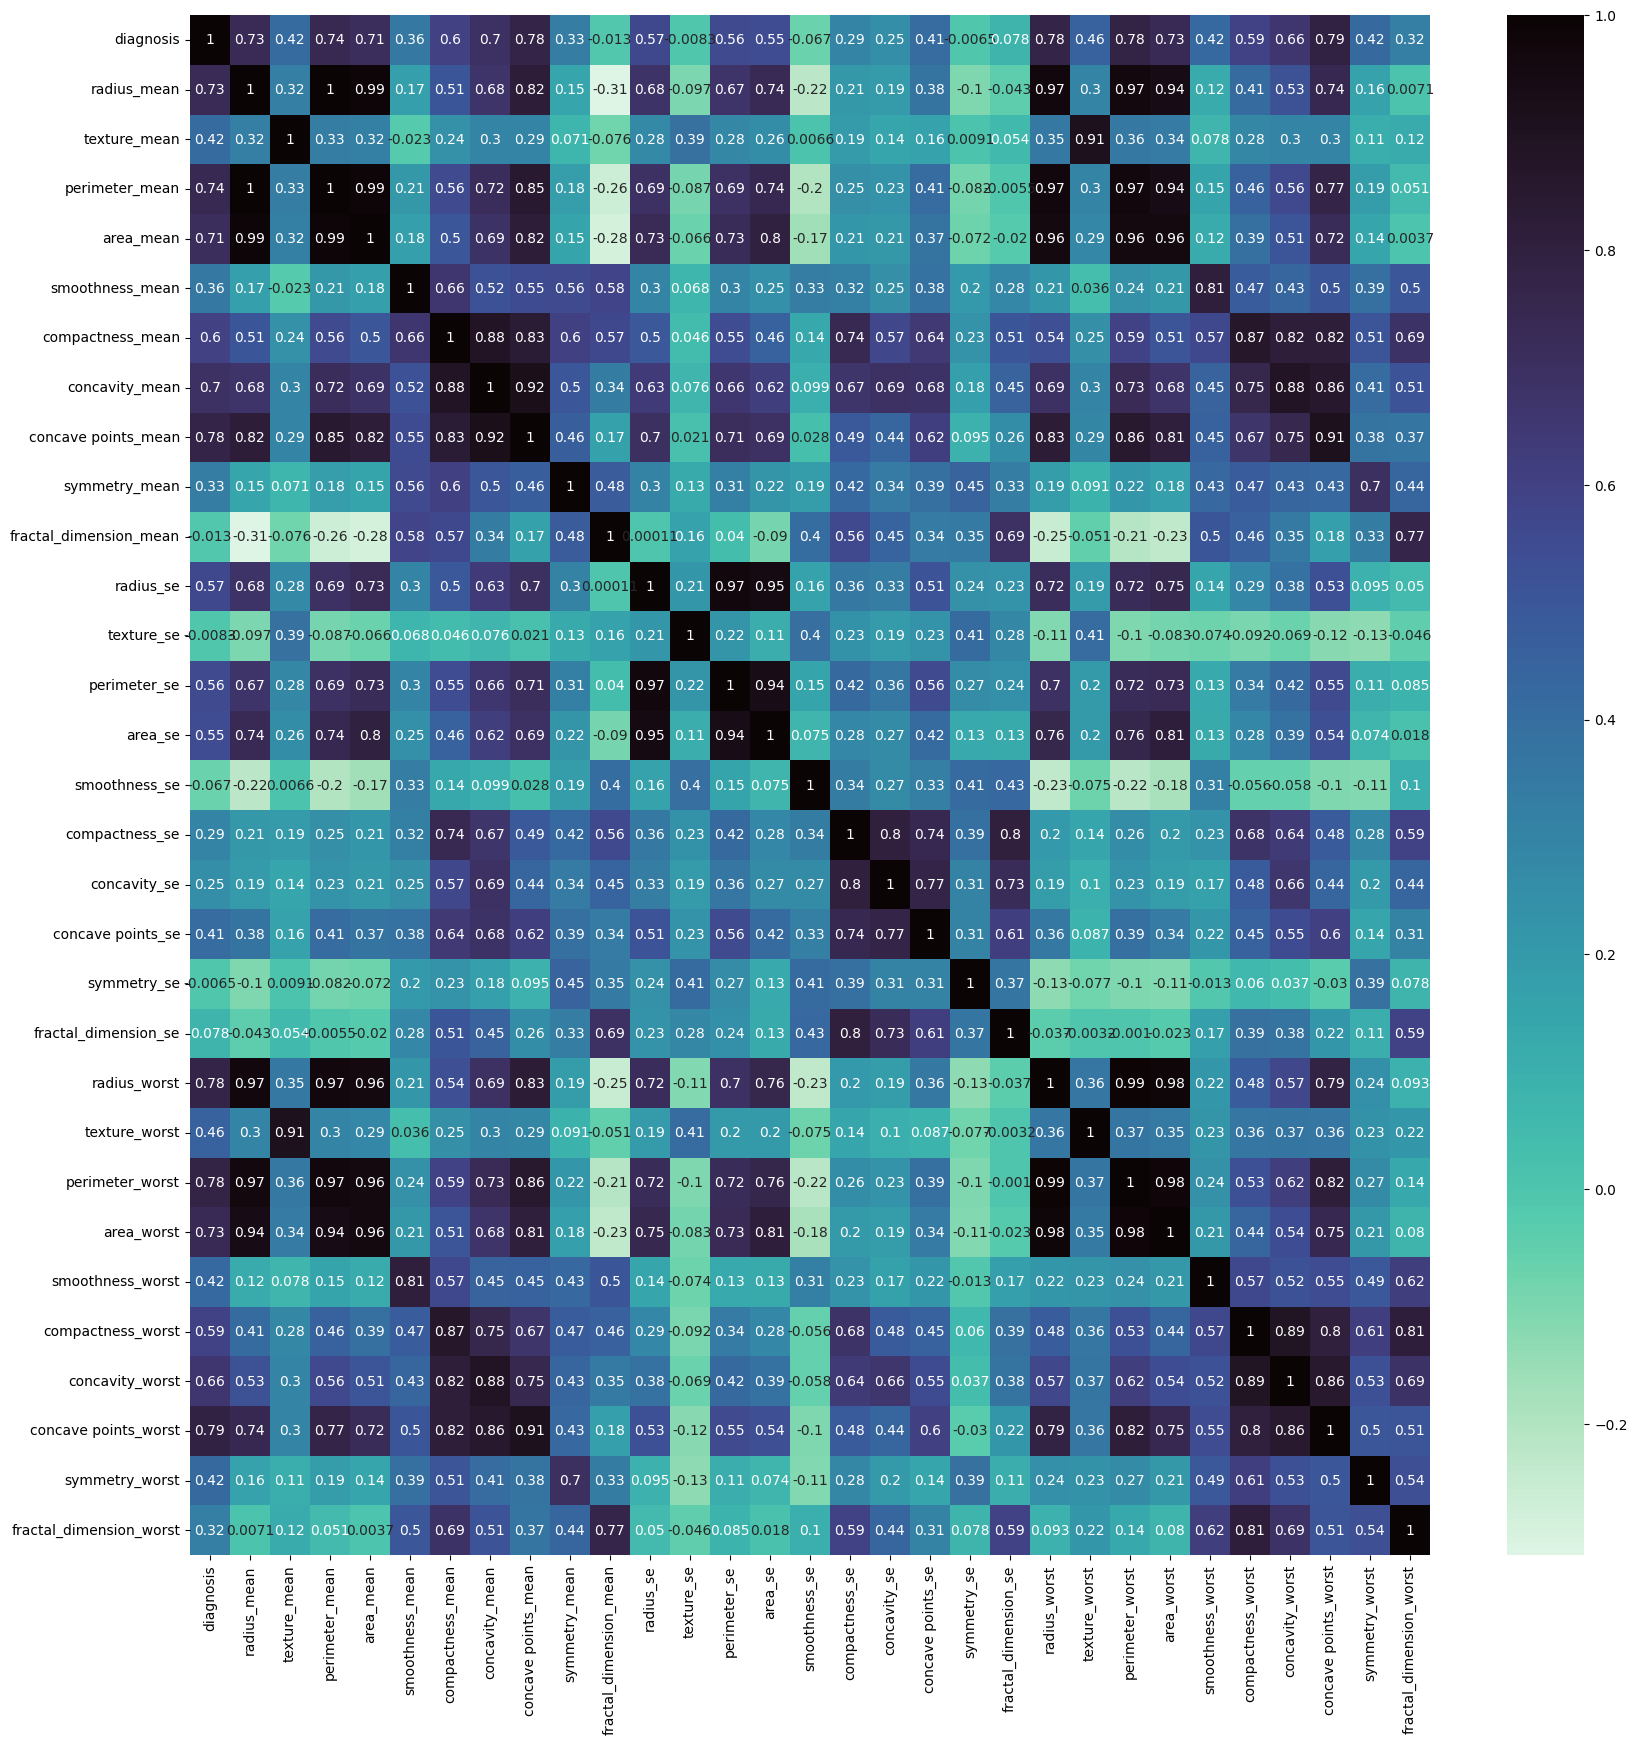

In [14]:
corr = df.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(corr, cmap='mako_r', annot=True)
plt.show()

In [15]:
# Get the absolute value of the correlation
cor_target = abs(corr['diagnosis'])

# select highly related features (threshold = 0.2)
relevant_features = cor_target[cor_target > 0.2]

# Collect the names of the features
names = [index for index, value in relevant_features.items()]

# Drop the target variable from the results
names.remove('diagnosis')

print(names)

['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'radius_se', 'perimeter_se', 'area_se', 'compactness_se', 'concavity_se', 'concave points_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [16]:
X = df[names].values

### Model Implementation

##### The main steps of PCA algorithm are as follows:
1. Compute the mean of the input data along each feature dimension.
2. Subtract the mean from the input data to center it around zero.
3. Compute the covariance matrix of the centered input data.
4. Compute the eigenvectors and eigenvalues of the covariance maxtrix.
5. Keep only the first n_components eigenvectors as the principle components. 
6. Compute the explained variance ratio for each principal component.
7. Transform the input data by projecting it onto the principle components.

The mean of the input data along each feature dimension is computed as:
$$\mu = \frac{1}{n} \sum_{i=1}^{n}x_i$$
where $n$ is the number of samples and $x_i$ is the feature vector of the $i$ th sample.

The centered input data is computed as 
$$x_{i}' = x_{i} - \mu$$
where $X$ is the input data matrix with shape $(n, p)$, $n$ is the number of samples, and $p$ is the number of features.

The covariance matrix of the centered input data is computed as:
$$C = \frac{1}{n - 1} \sum_{i=1}^{n} (x_{i}' \cdot x_{i}'^{T})$$
where $C$ is the covariance matrix with shape $(p, p)$.

The eigenvectors and eigenvalues of the covariance matrix are computed as:
$$C \cdot v_{i} = \lambda _{i} \cdot v_{i}$$
where $v_{i}$ is the $i$ th eigenvector with length $p$, and $\lambda _{i}$ is the corresponding eigenvalue.

Here, we keep only the first 'n_components' eigenvectors as the principle components. 


#### Finding the first n Principal Components
There are two approaches to go with this, we can either use SVD ir Eigenvalue value decomposition.

**Singular Value Decomposition**. is usuaslly represented in the following form:
$$
    \text{SVD}(X) = U\Sigma V^{T}
$$
when a matrix is actually transformed to this format, each component will have the following format:<br>
$U --$ left singular vectors
- Shape: $n \times n$ (or $n \times r$ in reduced form)
- Columns are orthonormal
- Describe patterns acorss sampels (row)

$\Sigma --$ singular values (these are just square root of the eigenvalules)
- Shape: $n \times d$ (or $r \times r$)
- This is a diagonall matrix (meaning that only the diagonal entries of the matrix are non zero)
- Each diagonal entry are the singular values and they are ordered in decreasing order
$$\sigma_{1} \geq \sigma_{2} \geq \sigma_{3} \geq ... \geq 0$$

$V^{T} --$ right singualr vectors
- Shape: $d \times d$  (or $r \times d$)
- Rows are orthonormal
- Columns of $V$ are directions in feature space

So in this case, we only need to retreive the top $n$ singular vectors (rows) from the $V^T$ matrix. Which is already ordered in terms of level of importance.

**Eigenvalue Decomposition (EVD)**
Works only for square matrix, represented in the following format:
$$A = Q \Lambda Q^{T}$$
- $A:$ your original square matrix
- $Q:$ columns are eigenvectors
- $\Lambda:$ diagonal matrix of eigenvalues
if $A$ is symmetrix (very important in ML), then:
$$A = Q \Lambda Q^{T}$$
and:
- Eigenvectors are **orthonormal** (Unit length, perpendicular)
- Eigenvalues are real numbers

**Walking through an example of finding the eigenvalue decomposition**
Assume we have the 2D matrix:

$$A = \begin{bmatrix}
    2 & 1\\
    1 & 2
    \end{bmatrix}$$

**1.0**. Finding the eigenvalues (the stretching amounts)

$$ \det(A - \lambda I) = 0$$

where:
- $I$ = identity matrix
- $\det$ = determinant (a number that tells you when a matrix squashes space flat)

**1.1**. Compute $A - \lambda I$

$$A - \lambda I = \begin{bmatrix} 
    2 - \lambda & 1 \\
    1 & 2 - \lambda
    \end{bmatrix}$$

**1.2**. Take the determinant

$$
\begin{aligned}
(2 - \lambda)^2 - 1 &= 0\\
(2 - \lambda)^2 &= 1\\
2 - \lambda &= \pm 1
\end{aligned}
$$

Eigenvalues are found: 
$$\lambda_{1} = 3, \lambda_{2} = 1$$

**2.0.**. Finding the eigenvectors (the directions)
Eigenvector for $\lambda = 3$
**2.1.** Plug into $(A - \lambda I) v = 0$

$$A - 3I = \begin{bmatrix}
    -1 & 1\\
    1 & -1
\end{bmatrix}$$

We then solve 

$$
\begin{bmatrix}
    -1 & 1\\
    1 & -1
\end{bmatrix} 
\begin{bmatrix}
x \\
y
\end{bmatrix} = 
\begin{bmatrix}
0 \\
0
\end{bmatrix}
$$

**2.2**
From the first row:

$$- x + y = 0 => y = x$$

So an eigenvector is:
$$v_1 = \begin{bmatrix} 1\\ 1\end{bmatrix}$$

**2.3.** Normalize<br>
Eigenvectors are usually unit vectors (length 1).
Length:<br>

$$\sqrt{1 ^2 + 1^2} = \sqrt{2}$$

Normalized eigenvector:

$$q_1 = \frac{1}{\sqrt{2}} \begin{bmatrix} 1 \\ 1 \end{bmatrix}$$

We utilized a similar process to compute the second eigenvector when $\lambda$ equates with 1.

##### Orthonormal vectors
- Just a quick definition check here, orthonormal vectors are a set of vectors that are both orthogonal (predendicular) and normalized (unit length).

The explained variance ratio for each principal component is computed as:
$$\text{Explained Variance Ratio}_{i} = \frac{\lambda _{i}}{\sum j = 1^{p} \lambda_{j}}$$
where $\text{ExplainedVarianceRatio}_{i}$ is the explained variance ratio for the $i$ th principal component.

The transformed data is computed as:
$$X\text{transformed} = X\text{centered} \cdot V$$

where V is the matrix of principal components with shape $(p, k)$, $X\text{centered}$ is the centered input data matrix with shape $(n,p)$, and $X \text{transformed}$ is the transformed data matrix with shape $(n, k)$

### Some Personal Notes:

- Taking the dot product of two matrices is the same as taking matrix multiplcation of two matrices.

In [34]:
class PCA:
    """
    Principal Component Analysis (PCA) class for dimensionality reduction.
    """

    def __init__(self, n_components):
        """
        Constructor method that initializes the PCA object with the number of components to retain.

        Args: 
        - n_components (int): Number of principal components to retain.
        """
        self.n_components = n_components
    
    def fit(self, X):
        """
        Fits the PCA model to the input data and computes the principal components.

        Args: 
        - X (numpy.ndarray): Input data matrix with shape (n_samples, n_features)
        """
        # Compute the mean of the input data along each feature dimension.
        mean = np.mean(X, axis = 0)

        # Subtract the mean from the input data to center it around zero.
        X = X - mean  # centered value

        # Compute the covariance matrix of the centered input data.
        cov = np.cov(X.T)  # Recall that covariance matrices are always real and symmetric, which makes it a Hermitian matrix.

        # Compute the eigenvectors and eigenvalues of the covariance matrix.
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        
        # Reverse the order of the eigenvalues and eigenvectors
        eigenvalues = eigenvalues[::-1]
        eigenvectors = eigenvectors[:, ::-1]

        # Keep only the first n_components eigenvectors as the principal components
        self.components = eigenvectors[:, :self.n_components]

        # Compute the explained variance ration for each principal component
        # Compute the total variance of the input data
        total_vairance = np.sum(np.var(X, axis = 0))

        # compute the variance explained by each principal component
        self.explained_variances = eigenvalues[:self.n_components]

        # Compute the explained variance ration for each principal component
        self.explained_variances_ratio_ = self.explained_variances / total_vairance
    
    def transform(self, X):
        """
        Transforms the input data by projecting it onto the principal components.
        
        Args:
        - X (numpy.ndarray): Input data matrix with shape (n_samples, n_features).

        Returns:
        - transformed_data (numpy.ndarray): Transformed data matrix with shape (n_samples, n_components) 
        """

        # Center the input data around zero using the mean computed during the fit step.
        X = X - np.mean(X, axis = 0)

        # Project the centered input data onto the principle components
        transformed_data = np.dot(X, self.components)
        return transformed_data

    def fit_transform(self, X):
        """
        Fits the PCA model to the input data and computes the principal components then transforms the input data by projecting it onto the principal components.
        
        Args:
        - X (numpy.ndarray): Input data matrix with shape (n_samples, n_features)
        """
        self.fit(X)
        transformed_data = self.transform(X)
        return transformed_data



In [35]:
# This is a again a practice snippet that helps us understand how pandas axis operate. 
# In 2D arrays, axis= 0 enforces the operation will go from top to bottom, axis=1 enforces the operation 
# to go from left to right.

sample = pd.DataFrame([[1, 2, 3],
                       [3, 6, 7],
                       [6, 9, 2]])
mean = np.mean(sample, axis = 1)
print(mean.shape)
cov = np.cov(sample, rowvar=True)
 
# Both np.linalg.eigh() and np.linalg.eig() are tools used for finding eigenvalues and eigenvectors, but each are made for a different kind of matrix.
eigenvalh, eigenvectorh = np.linalg.eigh(cov)   # works on any square matrix 
eigenval, eigenvector = np.linalg.eig(cov)  # works only for nice, symmetric matrices, but safer and better to use.

print("eigenvalues hermitian: ")
print(eigenvalh)
print("eigenvector hermitian: ")
print(eigenvectorh)
print(eigenvectorh[:, ::-1])

print("--------------------")
print("eigenval")
print(eigenval)
print("eigenvector")
print(eigenvector)


(3,)
eigenvalues hermitian: 
[-6.76771924e-16  4.21152513e+00  1.34551415e+01]
eigenvector hermitian: 
[[ 0.92035799  0.33829073 -0.19621559]
 [-0.38348249  0.87906854 -0.28316015]
 [ 0.0766965   0.33585395  0.93878633]]
[[-0.19621559  0.33829073  0.92035799]
 [-0.28316015  0.87906854 -0.38348249]
 [ 0.93878633  0.33585395  0.0766965 ]]
--------------------
eigenval
[1.34551415e+01 3.76434994e-16 4.21152513e+00]
eigenvector
[[-0.19621559 -0.92035799  0.33829073]
 [-0.28316015  0.38348249  0.87906854]
 [ 0.93878633 -0.0766965   0.33585395]]


#### Use Cases

In [36]:

pca = PCA(2)
pca.fit(X)


In [37]:
pca.explained_variances_ratio_

array([0.98377428, 0.01620498])

It is clear to us that the first 2 principal components explained 100% of the variations!

In [38]:
X_transformed = pca.transform(X)

In [39]:
X_transformed[:, 1].shape

(569,)

In [41]:
fig = px.scatter(x=X_transformed[:, 0], y=X_transformed[:, 1])
fig.update_layout(
    title="PCA transformed data for breast cancer dataset",
    xaxis_title = "PC1", 
    yaxis_title = "PC2"
)

fig.show()

Considering that we had so many other features in the past, we have now successfully reduced the number of dimensions to 2. From the variation ratio, we know that these two components are sufficient to explain the entire data set. 